# Parallel execution of parameter scan

## 1D Run

In [1]:
import xarray as xr

import numpy as np

In [2]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [3]:
from func_parallel import run_model_test

In [4]:
from multiprocessing import Pool

In [5]:
def generate_iterable_parscan(parameter, par_range):
    return [{parameter:val} for val in par_range]

In [17]:
iter_scan = generate_iterable_parscan('N0__value', np.linspace(0.001,0.01, 25))

import time as tm
p = Pool(processes=20)
start = tm.time()
data = p.map(run_model_test, iter_scan)
end = tm.time()
p.close()
print(round(end-start,5),"seconds")

11.188 seconds


In [18]:
simple_out = run_model_test(iter_scan[0])

In [19]:
list(iter_scan[0].values())[0]

0.001

In [20]:
def unpack_par_scan(iterable):
    var = list(iterable[0].keys())[0]
    i_tot=len(iterable)
    
    dat_out = []
    for dat,i, val in zip(data,range(i_tot),iterable) :
        dat_out.append(dat.assign_coords({var:list(val.values())[0]}).expand_dims(var))

    data_combined = xr.combine_by_coords(dat_out)
    
    return data_combined

In [21]:
outtt = unpack_par_scan(iter_scan)

outtt

<xarray.Dataset> Size: 63MB
Dimensions:                                         (N0__value: 25, zoo: 4,
                                                     time: 5000, phyto: 3,
                                                     full: 7, clock: 2)
Coordinates:
  * N0__value                                       (N0__value) float64 200B ...
  * clock                                           (clock) int64 16B 0 1
  * phyto                                           (phyto) float64 24B 0.63 ...
  * time                                            (time) float64 40kB 0.0 ....
  * zoo                                             (zoo) float64 32B 6.3 ......
Dimensions without coordinates: full
Data variables: (12/56)
    Core__solver_type                               (N0__value) <U9 900B 'sol...
    GGE__R                                          (N0__value) float64 200B ...
    GGE__alpha                                      (N0__value) float64 200B ...
    GGE__assimilated_consumer                       (N0__value) <U1 100B 'Z' ...
    GGE__assimilation_value                         (N0__value, zoo, time) float64 4MB ...
    GGE__egested_detritus                           (N0__value) <U1 100B 'N' ...
    ...                                              ...
    Phytoplankton__phyto_index                      (N0__value, phyto) float64 600B ...
    Time__time_input                                (N0__value, time) int64 1MB ...
    Zooplankton__biomass                            (N0__value, zoo, time) float64 4MB ...
    Zooplankton__biomass_init                       (N0__value, zoo) float64 800B ...
    Zooplankton__biomass_label                      (N0__value) <U1 100B 'Z' ...
    Zooplankton__zoo_index                          (N0__value, zoo) float64 800B ...

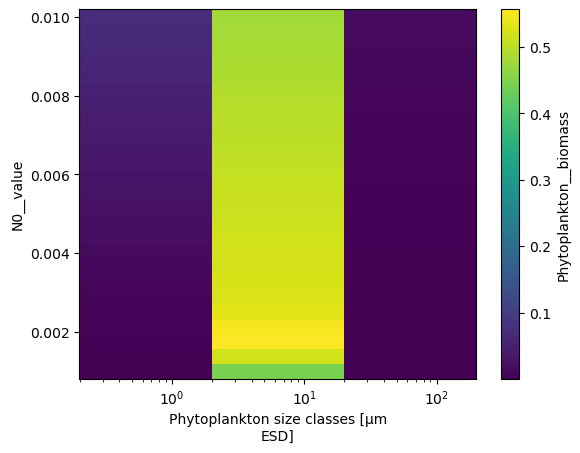

In [22]:
outtt.isel(time=slice(365*9,365*10)).Phytoplankton__biomass.mean(dim="time").plot(xscale='log', y='N0__value')

# 2D Par scan

In [28]:
iter_scan = generate_iterable_parscan('N0__value', np.linspace(0.001,0.01, 25))
iter_scan1 = iter_scan[:12]
iter_scan2 = iter_scan[12:]

In [32]:
iter_scan1
iter_scan2

[{'N0__value': 0.0028750000000000004},
 {'N0__value': 0.0032500000000000003},
 {'N0__value': 0.0036250000000000006},
 {'N0__value': 0.004},
 {'N0__value': 0.004375},
 {'N0__value': 0.004750000000000001},
 {'N0__value': 0.005125000000000001},
 {'N0__value': 0.0055000000000000005},
 {'N0__value': 0.005875000000000001},
 {'N0__value': 0.006250000000000001},
 {'N0__value': 0.006625000000000001},
 {'N0__value': 0.007000000000000001},
 {'N0__value': 0.007375000000000001},
 {'N0__value': 0.007750000000000001},
 {'N0__value': 0.008125},
 {'N0__value': 0.0085},
 {'N0__value': 0.008875000000000001},
 {'N0__value': 0.009250000000000001},
 {'N0__value': 0.009625000000000002},
 {'N0__value': 0.01}]

In [33]:
import time as tm
p = Pool(processes=20)
start = tm.time()
data_1 = p.map(run_model_test, iter_scan1)
data_2 = p.map(run_model_test, iter_scan2)
end = tm.time()
p.close()
print(round(end-start,5),"seconds")

13.30156 seconds


In [138]:
def generate_iterable_parscan(parameter, par_range):
    return [{parameter:val}for val in par_range]

def generate_iterable_2d_parscan(par1, par_range1, par2, par_range2):
    return [(par1,(val1, par2, generate_iterable_parscan(par2, par_range2))) for val1 in par_range1]

In [139]:
iter_scan_2d = generate_iterable_2d_parscan('N0__value', np.linspace(0.001,0.01, 5),
                             'HigherOrderMortality__rate', np.linspace(0.001,0.01, 5))

In [141]:
import time as tm
p = Pool(processes=20)
start = tm.time()
data2d = []
for iter_par1, (iter_val1, iter_par2, iter_vals2) in iter_scan_2d:
    data2d.append((iter_par1, (iter_val1, iter_par2, p.map(run_model_test, iter_vals2))))

end = tm.time()
p.close()
print(round(end-start,5),"seconds")

22.81044 seconds


In [160]:
unpack_2d_par_scan(data2d)

<xarray.Dataset> Size: 63MB
Dimensions:                                         (
                                                     HigherOrderMortality__rate: 5,
                                                     N0__value: 5, zoo: 4,
                                                     time: 5000, phyto: 3,
                                                     full: 7, clock: 2)
Coordinates:
  * HigherOrderMortality__rate                      (HigherOrderMortality__rate) float64 40B ...
  * N0__value                                       (N0__value) float64 40B 0...
  * clock                                           (clock) int64 16B 0 1
  * phyto                                           (phyto) float64 24B 0.63 ...
  * time                                            (time) float64 40kB 0.0 ....
  * zoo                                             (zoo) float64 32B 6.3 ......
Dimensions without coordinates: full
Data variables: (12/55)
    Core__solver_type                               (HigherOrderMortality__rate, N0__value) <U9 900B ...
    GGE__R                                          (HigherOrderMortality__rate, N0__value) float64 200B ...
    GGE__alpha                                      (HigherOrderMortality__rate, N0__value) float64 200B ...
    GGE__assimilated_consumer                       (HigherOrderMortality__rate, N0__value) <U1 100B ...
    GGE__assimilation_value                         (HigherOrderMortality__rate, N0__value, zoo, time) float64 4MB ...
    GGE__egested_detritus                           (HigherOrderMortality__rate, N0__value) <U1 100B ...
    ...                                              ...
    Phytoplankton__phyto_index                      (HigherOrderMortality__rate, N0__value, phyto) float64 600B ...
    Time__time_input                                (HigherOrderMortality__rate, N0__value, time) int64 1MB ...
    Zooplankton__biomass                            (HigherOrderMortality__rate, N0__value, zoo, time) float64 4MB ...
    Zooplankton__biomass_init                       (HigherOrderMortality__rate, N0__value, zoo) float64 800B ...
    Zooplankton__biomass_label                      (HigherOrderMortality__rate, N0__value) <U1 100B ...
    Zooplankton__zoo_index                          (HigherOrderMortality__rate, N0__value, zoo) float64 800B ...

In [156]:
dats_out = []
for var, (val, var2, dat) in data2d:

    dat_out = []
    for out in dat:
        #print(out)
        dat_out.append(out.assign_coords({var:val, var2:out[var2].values}).expand_dims(var).expand_dims(var2))

    data_combined = xr.combine_by_coords(dat_out)
        
    dats_out.append(data_combined)

xr.combine_by_coords(dats_out)

<xarray.Dataset> Size: 63MB
Dimensions:                                         (
                                                     HigherOrderMortality__rate: 5,
                                                     N0__value: 5, zoo: 4,
                                                     time: 5000, phyto: 3,
                                                     full: 7, clock: 2)
Coordinates:
  * HigherOrderMortality__rate                      (HigherOrderMortality__rate) float64 40B ...
  * N0__value                                       (N0__value) float64 40B 0...
  * clock                                           (clock) int64 16B 0 1
  * phyto                                           (phyto) float64 24B 0.63 ...
  * time                                            (time) float64 40kB 0.0 ....
  * zoo                                             (zoo) float64 32B 6.3 ......
Dimensions without coordinates: full
Data variables: (12/55)
    Core__solver_type                               (HigherOrderMortality__rate, N0__value) <U9 900B ...
    GGE__R                                          (HigherOrderMortality__rate, N0__value) float64 200B ...
    GGE__alpha                                      (HigherOrderMortality__rate, N0__value) float64 200B ...
    GGE__assimilated_consumer                       (HigherOrderMortality__rate, N0__value) <U1 100B ...
    GGE__assimilation_value                         (HigherOrderMortality__rate, N0__value, zoo, time) float64 4MB ...
    GGE__egested_detritus                           (HigherOrderMortality__rate, N0__value) <U1 100B ...
    ...                                              ...
    Phytoplankton__phyto_index                      (HigherOrderMortality__rate, N0__value, phyto) float64 600B ...
    Time__time_input                                (HigherOrderMortality__rate, N0__value, time) int64 1MB ...
    Zooplankton__biomass                            (HigherOrderMortality__rate, N0__value, zoo, time) float64 4MB ...
    Zooplankton__biomass_init                       (HigherOrderMortality__rate, N0__value, zoo) float64 800B ...
    Zooplankton__biomass_label                      (HigherOrderMortality__rate, N0__value) <U1 100B ...
    Zooplankton__zoo_index                          (HigherOrderMortality__rate, N0__value, zoo) float64 800B ...

# UNPACK DATA

In [159]:
def unpack_par_scan(iterable):
    var = list(iterable[0].keys())[0]
    i_tot=len(iterable)
    
    dat_out = []
    for dat,i, val in zip(data,range(i_tot),iterable) :
        dat_out.append(dat.assign_coords({var:list(val.values())[0]}).expand_dims(var))

    data_combined = xr.combine_by_coords(dat_out)
    
    return data_combined


def unpack_2d_par_scan(datasets):
    dats_out = []
    for var, (val, var2, dat) in datasets:
    
        dat_out = []
        for out in dat:
            #print(out)
            dat_out.append(out.assign_coords({var:val, var2:out[var2].values}).expand_dims(var).expand_dims(var2))
    
        data_combined = xr.combine_by_coords(dat_out)
            
        dats_out.append(data_combined)
    
    data_combined_2d = xr.combine_by_coords(dats_out)

    return data_combined_2d

In [128]:
for dat in dats_out[0]:
    print(dat)

NameError: name 'dats_out' is not defined

In [119]:
unpack_par_scan(data2d[0])

AttributeError: 'str' object has no attribute 'keys'

In [118]:
unpack_2d_par_scan(data2d)

AttributeError: 'str' object has no attribute 'keys'

In [27]:
outtt = unpack_par_scan(iter_scan)

outtt

<xarray.Dataset> Size: 63MB
Dimensions:                                         (N0__value: 25, zoo: 4,
                                                     time: 5000, phyto: 3,
                                                     full: 7, clock: 2)
Coordinates:
  * N0__value                                       (N0__value) float64 200B ...
  * clock                                           (clock) int64 16B 0 1
  * phyto                                           (phyto) float64 24B 0.63 ...
  * time                                            (time) float64 40kB 0.0 ....
  * zoo                                             (zoo) float64 32B 6.3 ......
Dimensions without coordinates: full
Data variables: (12/56)
    Core__solver_type                               (N0__value) <U9 900B 'sol...
    GGE__R                                          (N0__value) float64 200B ...
    GGE__alpha                                      (N0__value) float64 200B ...
    GGE__assimilated_consumer                       (N0__value) <U1 100B 'Z' ...
    GGE__assimilation_value                         (N0__value, zoo, time) float64 4MB ...
    GGE__egested_detritus                           (N0__value) <U1 100B 'N' ...
    ...                                              ...
    Phytoplankton__phyto_index                      (N0__value, phyto) float64 600B ...
    Time__time_input                                (N0__value, time) int64 1MB ...
    Zooplankton__biomass                            (N0__value, zoo, time) float64 4MB ...
    Zooplankton__biomass_init                       (N0__value, zoo) float64 800B ...
    Zooplankton__biomass_label                      (N0__value) <U1 100B 'Z' ...
    Zooplankton__zoo_index                          (N0__value, zoo) float64 800B ...

In [4]:
test_x

<bound method TESTRUN.run_model_test of <func_parallel.TESTRUN object at 0x114ad6cf0>>

In [8]:
test.run_model_test(1)

<xarray.Dataset> Size: 3MB
Dimensions:                                         (zoo: 4, time: 5000,
                                                     phyto: 3, full: 7, clock: 2)
Coordinates:
  * clock                                           (clock) int64 16B 0 1
  * phyto                                           (phyto) float64 24B 0.63 ...
  * time                                            (time) float64 40kB 0.0 ....
  * zoo                                             (zoo) float64 32B 6.3 ......
Dimensions without coordinates: full
Data variables: (12/57)
    Core__solver_type                               <U9 36B 'solve_ivp'
    GGE__R                                          float64 8B 0.45
    GGE__alpha                                      float64 8B 0.7
    GGE__assimilated_consumer                       <U1 4B 'Z'
    GGE__assimilation_value                         (zoo, time) float64 160kB ...
    GGE__egested_detritus                           <U1 4B 'N'
    ...                                              ...
    Phytoplankton__phyto_index                      (phyto) float64 24B 0.63 ...
    Time__time_input                                (time) int64 40kB 0 ... 4999
    Zooplankton__biomass                            (zoo, time) float64 160kB ...
    Zooplankton__biomass_init                       (zoo) float64 32B 0.1 ......
    Zooplankton__biomass_label                      <U1 4B 'Z'
    Zooplankton__zoo_index                          (zoo) float64 32B 6.3 ......

In [3]:
from multiprocessing import Pool
import numpy as np
pool = Pool(processes=20)

In [5]:
pool.map(func_parallel.test_x, range(2))

PicklingError: Can't pickle <class 'xsimlab.process.Backend'>: attribute lookup Backend on xsimlab.process failed

In [6]:
import dill

In [9]:
dill.dumps(func_parallel.test)

/Users/aoop/mambaforge/envs/XSO2025/lib/python3.13/site-packages/dill/_dill.py:422: PicklingWarning: Cannot locate reference to <class 'xsimlab.process.Backend'>.
  StockPickler.save(self, obj, save_persistent_id)
/Users/aoop/mambaforge/envs/XSO2025/lib/python3.13/site-packages/dill/_dill.py:422: PicklingWarning: Cannot pickle <class 'xsimlab.process.Backend'>: xsimlab.process.Backend has recursive self-references that trigger a RecursionError.
  StockPickler.save(self, obj, save_persistent_id)


PicklingError: Can't pickle <class 'xsimlab.process.Backend'>: it's not found as xsimlab.process.Backend

In [ ]:
from multiprocessing import Pool
import numpy as np
pool = Pool(processes=20)



pool.map(test, zip(range(10),range(10)))

Process SpawnPoolWorker-62:
Process SpawnPoolWorker-66:
Process SpawnPoolWorker-68:
Process SpawnPoolWorker-70:
Process SpawnPoolWorker-64:
Process SpawnPoolWorker-67:
Process SpawnPoolWorker-63:
Process SpawnPoolWorker-61:
Process SpawnPoolWorker-65:
Process SpawnPoolWorker-69:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/Users/aoop/mambaforge/envs/XSO2025/lib/python3.13/multiprocessing/process.py", line 313, in _bootstrap
    self.run()
    ~~~~~~~~^^
  File "/Users/aoop/mambaforge/envs/XSO2025/lib/python3.13/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/aoop/mambaforge/

In [5]:
def test(x):
    print(x)

In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# import necessary packages
import numpy as np
import matplotlib.pyplot as plt
import xso

from Stocketal2008_comps import (Nutrient, PhytoSizeSpectrum, ZooSizeSpectrum, 
    ConstantExternalNutrient, LinearForcingInput, 
    MonodGrowth_SizeBased, 
    StockGrazingMatrix, Stock_GGE_MatrixGrazing, 
    StockPhytoMortality, StockZooMortality, StockZooMortality_simpleinput)


Stocketal2008_mortsingleval = xso.create({
    # State variables
    'Nutrient': Nutrient,
    'Phytoplankton': PhytoSizeSpectrum,
    'Zooplankton': ZooSizeSpectrum,

    # Flows:
    'Inflow': LinearForcingInput,

    # Growth
    'Growth': MonodGrowth_SizeBased,

    # Grazing
    'Grazing': StockGrazingMatrix,
    'GGE': Stock_GGE_MatrixGrazing,

    # Mortality
    'PhytoMortality': StockPhytoMortality,
    'HigherOrderMortality': StockZooMortality_simpleinput,

    # Forcings
    'N0': ConstantExternalNutrient,
})


# number size classes of phytoplankton and zooplankton
P_num = 3
Z_num = 4

# create initial biomass
phyto_init = np.tile(1.5, (P_num))
zoo_init = np.tile(.1, (Z_num))

# calculate log-spaced size classes from ranges and total number
phyto_sizes = [0.63, 6.3, 63]
zoo_sizes = [6.3, 63, 630, 6300]

# Phytoplankton parameters
phyto_ks = [0.062, 0.45, 3.3]
phyto_mu0 = [1.0, 1.26, 0.42]
phyto_mortality = [1.0, 0, 0]
phyto_mort_exponent = [2.0, 1.0, 1.0]
phyto_recycling = [1.0, 0.0, 0.0]

# Zooplankton parameters
zoo_imax = [10.0, 3.3, 1.1, 0.36]
zoo_Ki = 3.0
zoo_frac_assim = 0.7  # alpha
zoo_frac_excreted = 0.45  # R
zoo_gge = 0.25
# prey availability: basically just 1 for size class below of Z and P, no other grazing! issa matrix 4 x 7
zoo_prey_avail = np.array([[1, 0, 0, 0, 0, 0, 0], # Z1
                          [0, 1, 0, 1, 0, 0, 0], # Z2
                          [0, 0, 1, 0, 1, 0, 0], # Z3
                          [0, 0, 0, 0, 0, 1, 0]]) # Z4

# dens dep prey exploitation factor
zoo_frac_egest_recycled = [1, 1, 0, 0]

# zoo mortality
zoo_higherordermortality = 0.0093
zoo_mortality_array = [0, 0, 0, zoo_higherordermortality]
zoo_mort_exponent = [0, 0, 0, 1]
zoo_frac_mortylity_recycled = [0, 0, 0, 0.5]



nutrient_input = 0.0053 # 0.017



model_setup = xso.setup(solver='solve_ivp', model=Stocketal2008_mortsingleval,
            time=np.arange(0,5000),
            input_vars={
                    # State variables
                    'Nutrient':{'value_label':'N','value_init':1.0},
                    'Phytoplankton':{'biomass_label':'P','biomass_init':phyto_init, 'phyto_index':phyto_sizes},
                 
                    'Zooplankton':{'biomass_label':'Z','biomass_init':zoo_init, 'zoo_index': zoo_sizes},
                
                    # Flows:
                    'Inflow':{'forcing':'N0', 'rate':1., 'var':'N'},
                
                    # Growth
                    'Growth':{'resource':'N', 'consumer':'P', 'halfsat':phyto_ks, 'mu_max':phyto_mu0},

                    # Grazing
                    'Grazing':{'resource':'P', 'consumer':'Z', 'Imax':zoo_imax, 'KsZ':zoo_Ki, 'phiPZ':zoo_prey_avail},
                    'GGE':{'grazed_phyto':'P', 'grazed_zoo':'Z', 'assimilated_consumer':'Z', 'egested_detritus':'N', 
                           'R':zoo_frac_excreted, 'alpha':zoo_frac_assim, 'f_I':zoo_frac_egest_recycled, 'gge':zoo_gge},
                
                    # Mortality
                    'PhytoMortality':{'population':'P', 'nutrient':'N', 'rate':phyto_mortality, 'exponent':phyto_mort_exponent, 'recycling':phyto_recycling},
                    'HigherOrderMortality':{'population':'Z', 'nutrient':'N', 'rate':zoo_higherordermortality, 'exponent':zoo_mort_exponent, 'recycling':zoo_frac_mortylity_recycled},

                    # Forcings
                    'N0':{'forcing_label':'N0', 'value':nutrient_input},
            })

In [2]:
out = xso.run_par_scan(Stocketal2008_mortsingleval, 1, 1)
out

A fatal error has occured during the function execution
Traceback (most recent call last):
  File "/Users/aoop/mambaforge/envs/XSO2025/lib/python3.13/site-packages/ppft/__main__.py", line 84, in run
    __fname, __fobjs = self.t.creceive(preprocess)
                       ~~~~~~~~~~~~~~~^^^^^^^^^^^^
  File "/Users/aoop/mambaforge/envs/XSO2025/lib/python3.13/site-packages/ppft/transport.py", line 114, in creceive
    self.rcache[hash1] = tuple(map(preprocess, (msg, )))[0]
                         ~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/aoop/mambaforge/envs/XSO2025/lib/python3.13/site-packages/ppft/__main__.py", line 49, in preprocess
    fobjs = [compile(fsource, '<string>', 'exec') for fsource in fsources]
             ~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<string>", line 592
    model = <xsimlab.Model (13 processes, 42 inputs)>
            ^
SyntaxError: invalid syntax
 A fatal error has occured during the function execution
Traceback (most recent call last):
  File "/Us

[None, None, None]

In [9]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from func_parallel import run_model_test

In [10]:
from multiprocessing import Pool

iterable = [i for i in range(25)]

if __name__ == '__main__':
    p = Pool(processes=50)
    data = p.map(run_model_test, iterable)
    p.close()

In [4]:
len(iterable)

10

In [16]:
i_tot=len(iterable)
for dat,i in zip(data,iterable) :
    data[i] = dat.assign_coords({'batchy':i}).expand_dims('batchy')
xr.combine_by_coords(data)

<xarray.Dataset> Size: 25MB
Dimensions:                                         (batchy: 10, zoo: 4,
                                                     time: 5000, phyto: 3,
                                                     full: 7, clock: 2)
Coordinates:
  * clock                                           (clock) int64 16B 0 1
  * phyto                                           (phyto) float64 24B 0.63 ...
  * time                                            (time) float64 40kB 0.0 ....
  * zoo                                             (zoo) float64 32B 6.3 ......
  * batchy                                          (batchy) int64 80B 0 1 ... 9
Dimensions without coordinates: full
Data variables: (12/57)
    Core__solver_type                               (batchy) <U9 360B 'solve_...
    GGE__R                                          (batchy) float64 80B 0.45...
    GGE__alpha                                      (batchy) float64 80B 0.7 ...
    GGE__assimilated_consumer                       (batchy) <U1 40B 'Z' ... 'Z'
    GGE__assimilation_value                         (batchy, zoo, time) float64 2MB ...
    GGE__egested_detritus                           (batchy) <U1 40B 'N' ... 'N'
    ...                                              ...
    Phytoplankton__phyto_index                      (batchy, phyto) float64 240B ...
    Time__time_input                                (batchy, time) int64 400kB ...
    Zooplankton__biomass                            (batchy, zoo, time) float64 2MB ...
    Zooplankton__biomass_init                       (batchy, zoo) float64 320B ...
    Zooplankton__biomass_label                      (batchy) <U1 40B 'Z' ... 'Z'
    Zooplankton__zoo_index                          (batchy, zoo) float64 320B ...

In [13]:
import xarray as xr

xr.combine_by_coords(data)
#xr.combine_by_coords(data, combine = 'nested', concat_dim='batch')

ValueError: Could not find any dimension coordinates to use to order the datasets for concatenation

In [2]:
"""
The ``processes`` module provides some convenience functions
for using parallel processes in python.

Adapted from http://stackoverflow.com/a/16071616/287297

Example usage:

    print prll_map(lambda i: i * 2, [1, 2, 3, 4, 6, 7, 8], 32, verbose=True)

Comments:

"It spawns a predefined amount of workers and only iterates through the input list
 if there exists an idle worker. I also enabled the "daemon" mode for the workers so
 that KeyboardInterupt works as expected."

Pitfalls: all the stdouts are sent back to the parent stdout, intertwined.

Alternatively, use this fork of multiprocessing: 
https://github.com/uqfoundation/multiprocess
"""

# Modules #
import multiprocessing
from tqdm import tqdm

################################################################################
def apply_function(func_to_apply, queue_in, queue_out):
    while not queue_in.empty():
        num, obj = queue_in.get()
        queue_out.put((num, func_to_apply(obj)))

################################################################################
def prll_map(func_to_apply, items, cpus=None, verbose=False):
    # Number of processes to use #
    if cpus is None: cpus = min(multiprocessing.cpu_count(), 32)
    # Create queues #
    q_in  = multiprocessing.Queue()
    q_out = multiprocessing.Queue()
    # Process list #
    new_proc  = lambda t,a: multiprocessing.Process(target=t, args=a)
    processes = [new_proc(apply_function, (func_to_apply, q_in, q_out)) for x in range(cpus)]
    # Put all the items (objects) in the queue #
    sent = [q_in.put((i, x)) for i, x in enumerate(items)]
    # Start them all #
    for proc in processes:
        proc.daemon = True
        proc.start()
    # Display progress bar or not #
    if verbose:
        results = [q_out.get() for x in tqdm(range(len(sent)))]
    else:
        results = [q_out.get() for x in range(len(sent))]
    # Wait for them to finish #
    for proc in processes: proc.join()
    # Return results #
    return [x for i, x in sorted(results)]

################################################################################
def test():
    def slow_square(x):
        import time
        time.sleep(2)
        return x**2
    objs    = range(20)
    squares = prll_map(slow_square, objs, 4, verbose=True)
    print("Result: %s" % squares)

In [3]:
test()

AttributeError: Can't get local object 'test.<locals>.slow_square'